<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
df = fetch_california_housing(as_frame=True).frame

In [12]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [16]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['MedHouseVal'].value_counts()

,count
MedHouseVal,
5.00001,965
1.37500,122
1.62500,117
1.12500,103
1.87500,93
...,...
0.34200,1
0.46200,1
3.52000,1


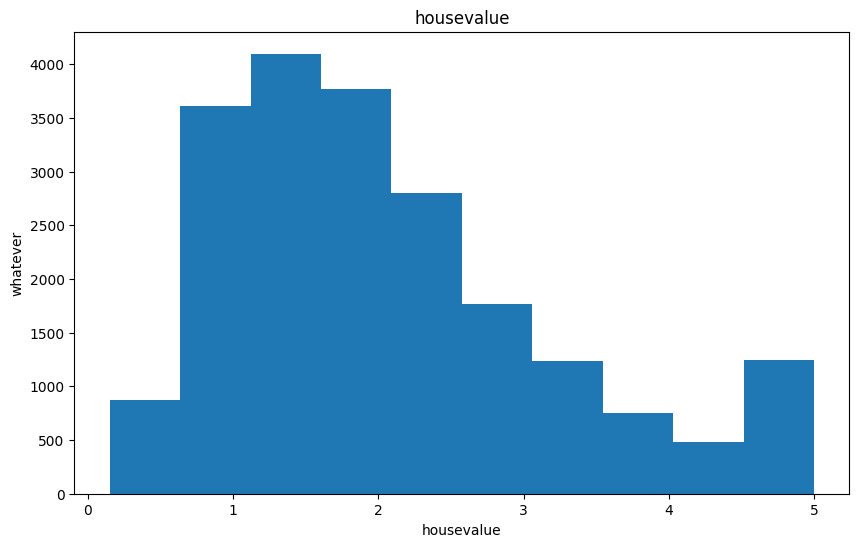

In [20]:
plt.figure(figsize=(10,6))
plt.hist(df['MedHouseVal'])
plt.xlabel('housevalue')
plt.ylabel('whatever')
plt.title('housevalue')
plt.show()

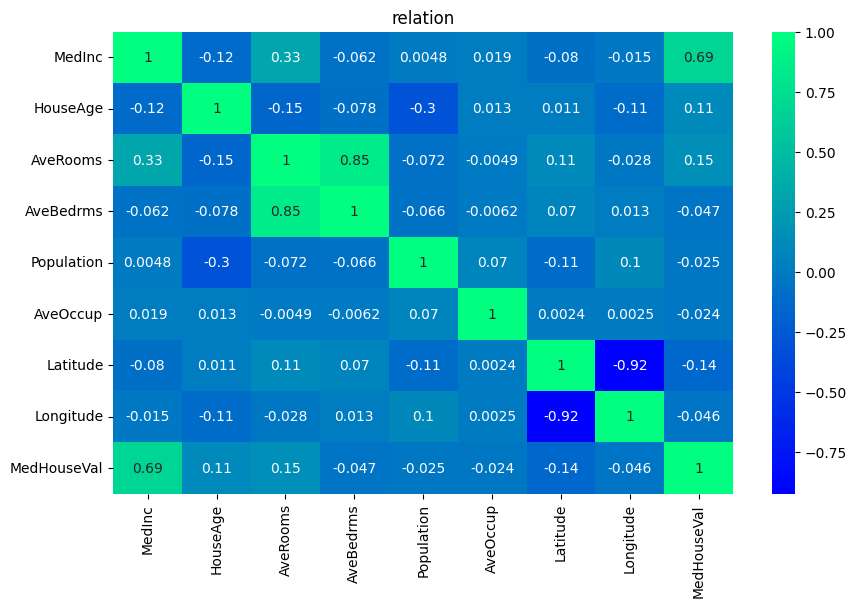

In [29]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='winter')
plt.title('relation')
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

In [32]:
x = df.drop('MedHouseVal',axis=1)

In [33]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [35]:
y= df['MedHouseVal']

In [36]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
Lr = LinearRegression()

In [52]:
Lr_scaled = LinearRegression()
Lr_scaled.fit(x_train_scaled, y_train) # Train the model on scaled training data

LinearRegression()

In [42]:
y_pred = Lr.predict(x_test)

In [43]:
y_pred

array([2.06737096, 2.98518758, 2.45333367, ..., 0.36999757, 2.06767227,
       1.94924073])

In [44]:
from sklearn.metrics import*

In [45]:
r2_score(y_test,y_pred)

0.6158083318595365

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) # Corrected: use transform, not fit_transform

In [47]:
x_train

array([[ 0.30672194, -0.29144351, -0.20405461, ..., -0.06851874,
         0.98175197, -1.33223155],
       [-0.59031548, -0.05351633, -0.0369578 , ...,  0.05219189,
         0.41606849,  0.08859193],
       [-0.88410549, -0.45006164, -0.09266354, ..., -0.05977704,
         1.9448164 , -0.99322805],
       ...,
       [ 0.30298911, -0.76729788,  0.35812867, ..., -0.01834449,
         1.10797886, -1.09792031],
       [-0.26172071,  0.26371992,  0.35959981, ..., -0.04693099,
        -1.32773263,  1.2451921 ],
       [-0.83804964,  1.84990116, -0.46749664, ..., -0.09824456,
         1.04252788, -1.34718758]])

In [53]:
y_pred_scaled = Lr_scaled.predict(x_test_scaled) # Predict using the scaled-trained model on scaled test data

In [49]:
y_pred_scaled

array([-37.07648315, -36.48945132, -36.98188182, ..., -37.85694341,
       -36.83754818, -37.22935187])

In [54]:
r2_score(y_test, y_pred_scaled)

0.6206006394407327